In [1]:
import pandas as pd
import numpy as np
from ipyfilechooser import FileChooser
import matplotlib.pyplot as plt
import os
import sys
sys.path.insert(0, os.path.abspath("."))
from kienzle_utils import MillingSignalUtils as MSU
from kienzle_model import KienzleModel


ModuleNotFoundError: No module named 'kienzle_utils'

In [ ]:

data_file_path = "G:\Mi unidad\Exchange\MscCD\Measurements_CutOpt"
data_info_file = "Experiment_C4240.xlsx"
fc = FileChooser(data_file_path )   # starting directory
fc.filter_pattern = ["*.xlsx", "*.xls"]
display(fc)
##
complete_info_file_path =   data_file_path + '\\' + data_info_file
print(complete_info_file_path)

FileChooser(path='G:\Mi unidad\Exchange\MscCD\Measurements_CutOpt', filename='', title='', show_hidden=False, …

G:\Mi unidad\Exchange\MscCD\Measurements_CutOpt\Experiment_C4240.xlsx


In [ ]:
df_info = pd.read_excel(complete_info_file_path)   # fc.selected holds the full path
print(f"Loaded: {data_info_file}")
df_info.head()
##

df_info = pd.read_excel(complete_info_file_path)
print(f"Loaded: {complete_info_file_path}")
df_info.head()

Loaded: Experiment_C4240.xlsx
Loaded: G:\Mi unidad\Exchange\MscCD\Measurements_CutOpt\Experiment_C4240.xlsx


,Ae (mm),Ap (mm),f (mm/min),N (rpm),R (mm),Z,fz,Vc,SinuTraceFile (*.csv)
0,40,1.0,632.00,2108.0,20,2,0.149905,264.899093,Trace_0623_164010.csv
1,38,1.0,632.00,2108.0,20,2,0.149905,264.899093,Trace_0623_164120.csv
2,32,1.0,632.00,2108.0,20,2,0.149905,264.899093,Trace_0623_164227.csv
3,26,1.0,632.00,2108.0,20,2,0.149905,264.899093,Trace_0623_164408.csv
4,40,1.0,505.92,1686.4,20,2,0.150000,211.919274,Trace_0623_164544.csv


In [ ]:
dataset = []
cut_param = df_info
for cut_exper_idx in range(len(cut_param)):

    # --- load the measurement file for this cut ---
    cutting_test = data_file_path + '\\all\\' + df_info['SinuTraceFile (*.csv)'][cut_exper_idx]
    df = pd.read_csv(cutting_test)

    # --- cutting parameters for this file ---
    cut_param_current_process = cut_param.iloc[cut_exper_idx]
    f      = cut_param_current_process['f (mm/min)']
    r_tool = cut_param_current_process['R (mm)']

    # --- compute ramp-up offset ---
    s_offset  = 5
    s_ramp_up = 2 * r_tool + s_offset
    t_ramp_up = s_ramp_up / f * 60

    # --- find index where actual cutting starts ---
    idx = np.argmax(df['time'] > t_ramp_up)

    # --- extract no-load interval for friction compensation ---
    s_friction_trace = r_tool + s_offset
    t_friction_trace = s_friction_trace / f * 60
    idx_frict        = np.argmax(df['time'] > t_friction_trace)
    mean_iq_frict    = np.mean(df['+/Nck/!SD/nckServoDataActCurr32 [u1; 4]'][:idx_frict])
    std_iq_no_load   = np.std(df['+/Nck/!SD/nckServoDataActCurr32 [u1; 4]'][:idx_frict])    
      # --- append this cut as one sample ---
    dataset.append({
        "ap":  float(cut_param_current_process['Ap (mm)']),
        "fz":  float(cut_param_current_process['fz']),
        "n":   float(cut_param_current_process['N (rpm)']),

        "mean_iq_no_load": float(mean_iq_frict), 
        "std_iq_no_load" : float(std_iq_no_load)
    })

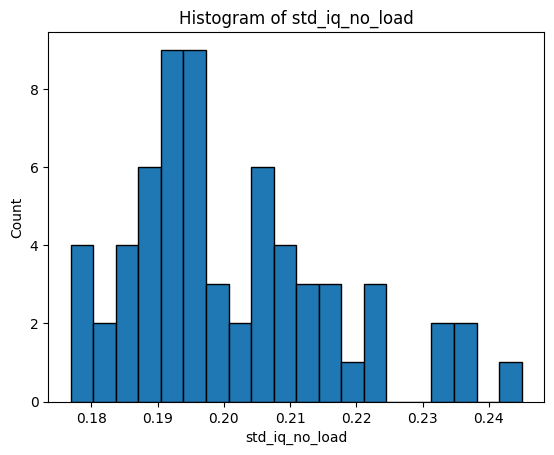

In [ ]:


std_values = [item["std_iq_no_load"] for item in dataset]
plt.hist(std_values, bins=20, edgecolor="black")
plt.xlabel("std_iq_no_load")
plt.ylabel("Count")
plt.title("Histogram of std_iq_no_load")
plt.show()

In [ ]:
from scipy import stats
from sklearn.mixture import GaussianMixture


# data = std_iq_no_load values (1D array)
data = np.asarray(std_values, dtype=float) 
# --- Candidate 1: Gamma ---
gamma_params = stats.gamma.fit(data, floc=0)  # fix loc=0 since std >= 0
gamma_aic = 2*len(gamma_params) - 2*np.sum(stats.gamma.logpdf(data, *gamma_params))

# --- Candidate 2: Lognormal ---
lognorm_params = stats.lognorm.fit(data, floc=0)
lognorm_aic = 2*len(lognorm_params) - 2*np.sum(stats.lognorm.logpdf(data, *lognorm_params))

# --- Candidate 3: 2-component GMM ---
gmm = GaussianMixture(n_components=2, random_state=0).fit(data.reshape(-1, 1))
gmm_aic = gmm.aic(data.reshape(-1, 1))

print(f"Gamma AIC:     {gamma_aic:.2f}, params: {gamma_params}")
print(f"Lognormal AIC: {lognorm_aic:.2f}, params: {lognorm_params}")
print(f"GMM AIC:       {gmm_aic:.2f}, weights: {gmm.weights_}, "
      f"means: {gmm.means_.ravel()}, stds: {np.sqrt(gmm.covariances_).ravel()}")

# K-S goodness of fit for the unimodal candidates
ks_gamma = stats.kstest(data, 'gamma', args=gamma_params)
ks_lognorm = stats.kstest(data, 'lognorm', args=lognorm_params)
print("KS Gamma:", ks_gamma)
print("KS Lognormal:", ks_lognorm)

Gamma AIC:     -348.89, params: (176.48745914278518, 0, np.float64(0.0011405271934592216))
Lognormal AIC: -349.95, params: (np.float64(0.07472671816083104), 0, np.float64(0.20071875288920976))
GMM AIC:       -352.27, weights: [0.58439056 0.41560944], means: [0.19220356 0.21406348], stds: [0.00800165 0.01430301]
KS Gamma: KstestResult(statistic=np.float64(0.13398236554692733), pvalue=np.float64(0.18338459696761256), statistic_location=np.float64(0.19699287946373567), statistic_sign=np.int8(1))
KS Lognormal: KstestResult(statistic=np.float64(0.13024309740596757), pvalue=np.float64(0.20867657276894813), statistic_location=np.float64(0.19699287946373567), statistic_sign=np.int8(1))


Reconstructed sample size: 64
Gamma fit -> shape (a) = 161.763, loc = 0.00000, scale = 0.001242
Implied mean = 0.20096, variance = 0.0002497
KS test: stat=0.1635, p-value=0.0580


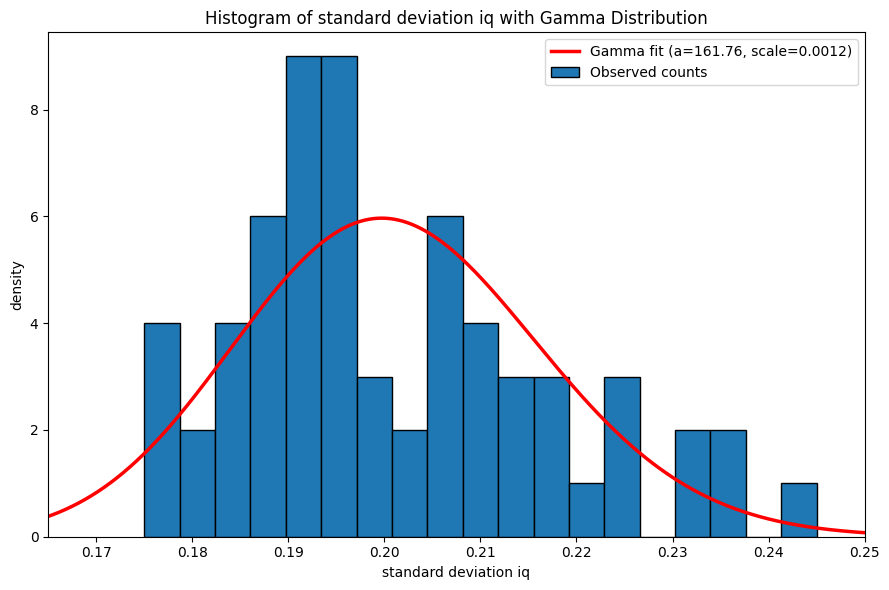

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import sys
sys.path.append("..\py\src")
from kienzle_model import KienzleModel #as kimo

# -------------------------------------------------------------------
# 1) Reconstruct an approximate sample from the histogram bin counts
#    (read off from the provided plot of std_iq_no_load)
# -------------------------------------------------------------------
bin_edges = np.linspace(0.175, 0.245, 20)  # 19 bins, width ~0.00368
counts = np.array([4, 2, 4, 6, 9, 9, 3, 2, 6, 4, 3, 3, 1, 3, 0, 2, 2, 0, 1])

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Build a pseudo-sample by repeating each bin center by its count
data = np.repeat(bin_centers, counts)
n_total = len(data)
print(f"Reconstructed sample size: {n_total}")

# -------------------------------------------------------------------
# 2) Fit a Gamma distribution (loc fixed at 0, since std >= 0)
# -------------------------------------------------------------------
shape_a, loc, scale = stats.gamma.fit(data, floc=0)
print(f"Gamma fit -> shape (a) = {shape_a:.3f}, loc = {loc:.5f}, scale = {scale:.6f}")
print(f"Implied mean = {shape_a*scale:.5f}, variance = {shape_a*scale**2:.7f}")

# Goodness of fit
ks_stat, ks_p = stats.kstest(data, 'gamma', args=(shape_a, loc, scale))
print(f"KS test: stat={ks_stat:.4f}, p-value={ks_p:.4f}")

# -------------------------------------------------------------------
# 3) Plot bar histogram (counts) with Gamma PDF overlay (scaled to counts)
# -------------------------------------------------------------------
bin_width = bin_edges[1] - bin_edges[0]

fig, ax = plt.subplots(figsize=(9, 6))

# Bar plot matching the original style
ax.bar(bin_centers, counts, width=bin_width, align='center',
       color='#1f77b4', edgecolor='black', linewidth=1.0,
       label='Observed counts')

# Gamma PDF, scaled so that area matches total count * bin width
x = np.linspace(0.16, 0.25, 400)
pdf = stats.gamma.pdf(x, shape_a, loc=loc, scale=scale)
pdf_scaled = pdf * n_total * bin_width

ax.plot(x, pdf_scaled, color='red', linewidth=2.5,
        label=f'Gamma fit (a={shape_a:.2f}, scale={scale:.4f})')

ax.set_title('Histogram of standard deviation iq with Gamma Distribution')
ax.set_xlabel('standard deviation iq')
ax.set_ylabel('density')
ax.legend()
ax.set_xlim(0.165, 0.25)

plt.tight_layout()
plt.savefig('results/std_iq_no_load_gamma_overlay.png', dpi=150)
plt.show()

In [ ]:
# Generate q from the cutting parameters using KienzleModel

model = KienzleModel(
        mc=0.25,
    kc11=1800.0,
    phi_in=0.0,
    phi_out=np.pi,
    fz=0.1,
    ap=2.0,
    omega=600.0,
    time=np.linspace(0, 0.5, 2500),   # 2500 samples
    z=4,
    r_tool=10.0,
    kappa_deg=90.0,
    km=1.3,
    gamma_shape=161.763,
    gamma_scale=0.001242,
    gamma_loc=0.0,
    seed=42,
)

def _as_scalar(value):
    arr = np.asarray(value)
    if arr.size == 1:
        return float(arr.reshape(-1)[0])
    return arr

q_values = None

# Try dataframe-level methods first
for method_name in ("generate_q", "predict_q", "compute_q", "calc_q", "q"):
    if hasattr(model, method_name):
        method = getattr(model, method_name)
        try:
            q_values = method(df_info)
            break
        except Exception:
            pass

# Fallback: row-wise evaluation
if q_values is None:
    q_values = []
    for _, row in df_info.iterrows():
        params = {
            "ap": float(row["Ap (mm)"]),
            "fz": float(row["fz"]),
            "n": float(row["N (rpm)"]),
            "ae": float(row["Ae (mm)"]),
            "r_tool": float(row["R (mm)"]),
            "z": int(row["Z"]),
            "vc": float(row["Vc"]),
        }

        q_row = 1#None
        for method_name in ("predict_q", "compute_q", "calc_q", "q"):
            if hasattr(model, method_name):
                method = getattr(model, method_name)
                try:
                    q_row = method(**params)
                    break
                except TypeError:
                    try:
                        q_row = method(
                            params["ap"], params["fz"], params["n"],
                            params["ae"], params["r_tool"], params["z"]
                        )
                        break
                    except Exception:
                        pass

        if q_row is None:
            raise AttributeError("No compatible KienzleModel method found for q generation.")

        q_values.append(_as_scalar(q_row))

    q_values = np.asarray(q_values, dtype=float)

cut_param_q = df_info.copy()
cut_param_q["q"] = q_values

print(cut_param_q[["Ap (mm)", "fz", "N (rpm)", "q"]].head())

   Ap (mm)        fz  N (rpm)    q
0      1.0  0.149905   2108.0  1.0
1      1.0  0.149905   2108.0  1.0
2      1.0  0.149905   2108.0  1.0
3      1.0  0.149905   2108.0  1.0
4      1.0  0.150000   1686.4  1.0


In [ ]:
import numpy as np
from scipy import stats

# -------------------------------------------------------------------
# Gamma distribution fitted to std_iq_no_load (from earlier fit)
# -------------------------------------------------------------------
shape_a, loc, scale = 161.763, 0.0, 0.001242  # replace with your real fitted values

# -------------------------------------------------------------------
# modeled_iq: your noiseless modeled signal, length 2500
# -------------------------------------------------------------------
n_samples = 2500
# modeled_iq = ... (your simulated/modeled signal, shape (2500,))

# Step 1: draw a realistic noise level (sigma) for this run
sigma_no_load = stats.gamma.rvs(shape_a, loc=loc, scale=scale)
print(f"Sampled sigma_no_load = {sigma_no_load:.5f}")

# Step 2: generate Gaussian noise with that sigma, add to every sample
noise = np.random.normal(loc=0.0, scale=sigma_no_load, size=n_samples)
modeled_iq = 0.0

iq_simulated = modeled_iq + noise

Sampled sigma_no_load = 0.16470


In [ ]:
n_runs = 200

iq_simulated_runs = np.zeros((n_runs, n_samples))
sigma_samples = stats.gamma.rvs(shape_a, loc=loc, scale=scale, size=n_runs)

for i, sigma in enumerate(sigma_samples):
    noise = np.random.normal(0.0, sigma, size=n_samples)
    iq_simulated_runs[i, :] = modeled_iq + noise

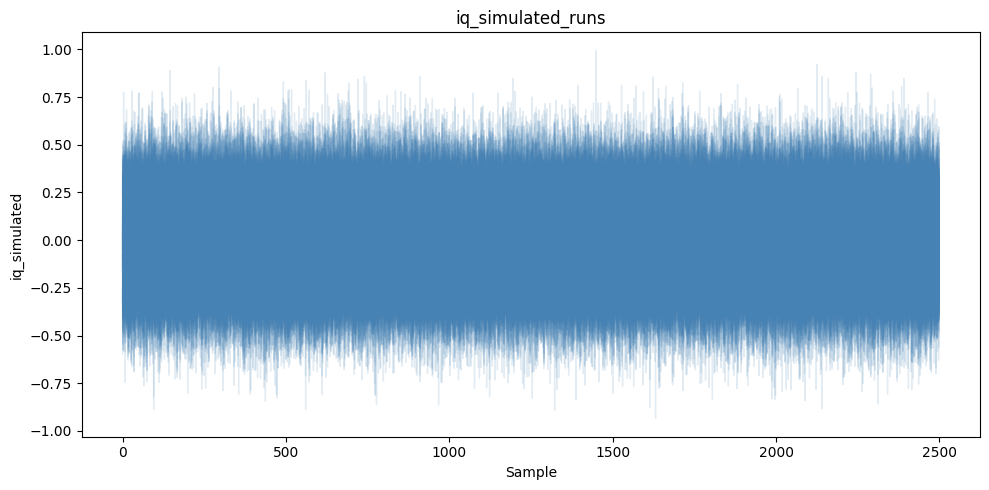

In [ ]:
plt.figure(figsize=(10, 5))

for run in iq_simulated_runs:
    plt.plot(run, color="steelblue", alpha=0.15, linewidth=1)

plt.xlabel("Sample")
plt.ylabel("iq_simulated")
plt.title("iq_simulated_runs")
plt.tight_layout()
plt.show()